Irene Lega, Benedetta Taricco, Matteo Gobbato. 
# Top Quark Tagging, notebook 3.
# BARREN-PLATEAU

In questo notebook, che segue a VQAsemplice e VQAreuploading, si analizzano gli effetti del barren plaeau nei circuiti analizzati in precedenza. In particolare, si plotta il grafico della varianza dei gradenti della loss vs il numero di qubits per entrambi i circuiti senza re-uploading (VQAsemplice) e per per il circuito finale con re-uploading, composto da 2 layer (VQAreuploading).

# Autoencoder
Con il solito autoencoder sinkhorn (sono stati rimossi i print ad ogni epoch) si comprimono le features:

DataLoader pronto! Numero batch: 40

Training AE | latent=16, early_stop=30



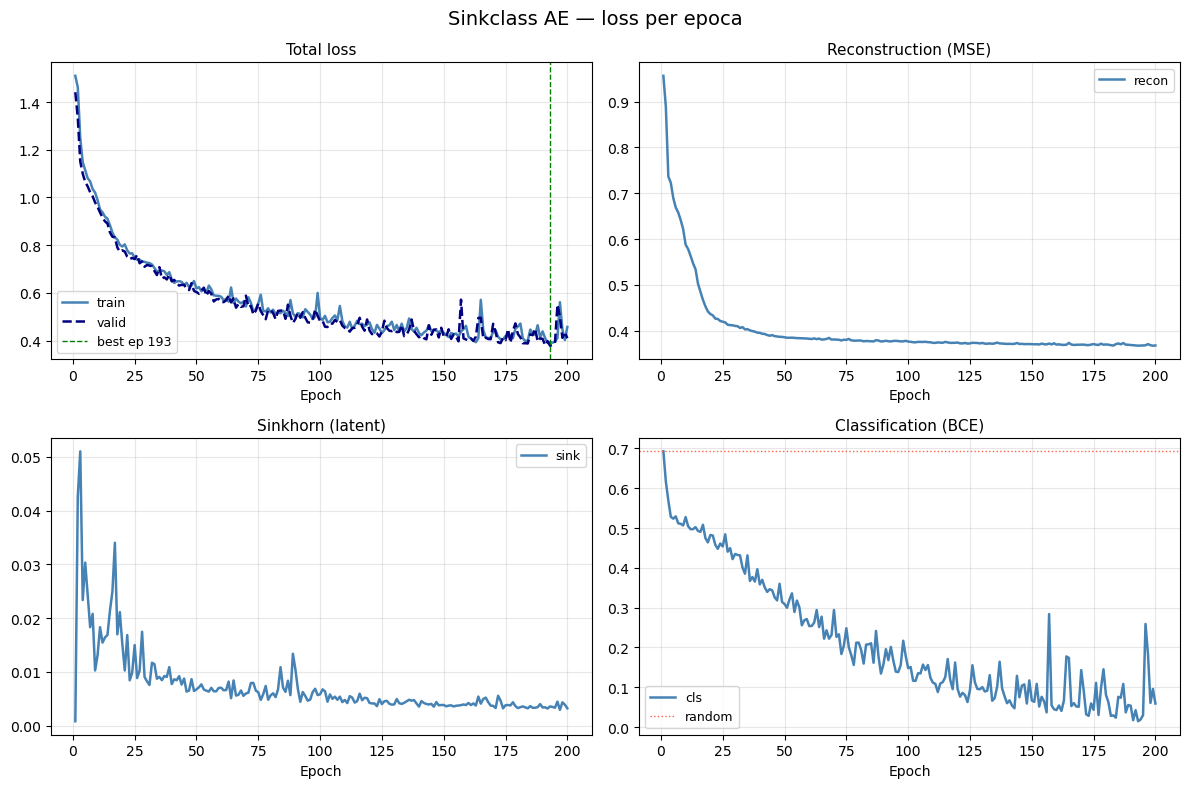

X_tr shape: (8000, 400)
X_te shape: (2000, 400)
latent_train shape: (8000, 16)
latent_test shape: (2000, 16)
X_train shape: (8000, 16)
X_test shape: (2000, 16)


In [1]:
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import geomloss
import matplotlib.pyplot as plt
import os
import pennylane as qml
import pennylane.numpy as pnp
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# ================================================================
# PARTE 1 — CARICA DATI
# ================================================================

infile = "train_nominal_000.h5"
f = h5py.File(infile, 'r')
Njet = 10000
NConstituents = 100

clus_E   = f['fjet_clus_E'][:Njet,   :NConstituents]
clus_eta = f['fjet_clus_eta'][:Njet,  :NConstituents]
clus_phi = f['fjet_clus_phi'][:Njet,  :NConstituents]
clus_pt  = f['fjet_clus_pt'][:Njet,   :NConstituents]
labels   = f["labels"][:Njet]

X = np.concatenate([
    clus_pt.reshape(Njet, -1),
    clus_eta.reshape(Njet, -1),
    clus_phi.reshape(Njet, -1),
    clus_E.reshape(Njet, -1)
], axis=1)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(labels, dtype=torch.float32)
dataset  = TensorDataset(X_tensor, y_tensor)

train_loader = DataLoader(dataset, batch_size=256, shuffle=True)
valid_loader = DataLoader(dataset, batch_size=512, shuffle=False)
print("DataLoader pronto! Numero batch:", len(train_loader))


# ================================================================
# PARTE 2 — AUTOENCODER SINKCLASS
# ================================================================

class AE_sinkclass(nn.Module):
    def __init__(self, device="cpu", hpars=None):
        super().__init__()
        self.device = device
        self.hp = {
            "ae_type":          "sinkclass",
            "ae_layers":        [400, 256, 128, 64, 32, 16],  # latent = 16
            "lr":               0.0005,
            "adam_betas":       (0.9, 0.999),
            "labels_dimension": 2,
            "class_weight":     0.7,
            "sinkh_weight":     0.3,
            "class_layers":     [64, 32, 16, 1],
        }
        if hpars:
            self.hp.update({k: hpars[k] for k in hpars.keys() & self.hp.keys()})

        latent_dim = self.hp["ae_layers"][-1]   # 16
        labels_dim = self.hp["labels_dimension"]

        self.encoder    = self._build_mlp(self.hp["ae_layers"], final_activation=False)
        self.decoder    = self._build_mlp(list(reversed(self.hp["ae_layers"])), final_activation=True)
        self.classifier = self._build_classifier([latent_dim] + self.hp["class_layers"])

        first_hidden = self.hp["ae_layers"][1]
        self.noise_enc_data = nn.Sequential(
            nn.Linear(self.hp["ae_layers"][0], first_hidden), nn.LeakyReLU(0.2),
            nn.Linear(first_hidden, first_hidden),            nn.LeakyReLU(0.2),
        )
        self.noise_enc_labl = nn.Sequential(
            nn.Linear(labels_dim, first_hidden), nn.LeakyReLU(0.2),
        )
        self.noise_gen = nn.Sequential(
            nn.Linear(2 * first_hidden, first_hidden), nn.LeakyReLU(0.2),
            nn.Linear(first_hidden, first_hidden // 2),  nn.LeakyReLU(0.2),
            nn.Linear(first_hidden // 2, latent_dim),
        )

        self.recon_loss_fn = nn.MSELoss(reduction="mean")
        self.class_loss_fn = nn.BCELoss(reduction="mean")
        self.laten_loss_fn = geomloss.SamplesLoss("sinkhorn", blur=0.05, scaling=0.95, diameter=0.01, debias=True)

        self.best_valid_loss   = float("inf")
        self.epochs_no_improve = 0
        self.early_stop_limit  = 30
        self.all_train_loss, self.all_valid_loss = [], []
        self.all_recon_loss, self.all_laten_loss, self.all_class_loss = [], [], []
        self.to(self.device)

    @staticmethod
    def _build_mlp(layers, final_activation=True):
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                mods.append(nn.ReLU(True))
            elif final_activation:
                mods.append(nn.Tanh())
        return nn.Sequential(*mods)

    @staticmethod
    def _build_classifier(layers):
        mods = []
        for i in range(len(layers) - 1):
            mods.append(nn.Linear(layers[i], layers[i + 1]))
            mods.append(nn.Sigmoid() if i == len(layers) - 2 else nn.LeakyReLU(0.2))
        return nn.Sequential(*mods)

    def _onehot(self, y_batch):
        B = y_batch.shape[0]
        y_map = torch.zeros(B, self.hp["labels_dimension"], device=y_batch.device)
        return y_map.scatter_(1, y_batch.long().reshape(-1, 1), 1.0)

    def _generate_noise(self, x_noise, y_onehot):
        return self.noise_gen(torch.cat([self.noise_enc_data(x_noise),
                                         self.noise_enc_labl(y_onehot)], dim=1))

    def forward(self, x):
        latent = self.encoder(x)
        return latent, self.classifier(latent), self.decoder(latent)

    def compute_loss(self, x_data, y_data):
        y_onehot     = self._onehot(y_data)
        latent, classif, recon = self.forward(x_data)
        latent_noise = self._generate_noise(torch.rand_like(x_data), y_onehot)
        recon_loss   = self.recon_loss_fn(recon, x_data)
        class_loss   = self.class_loss_fn(classif.flatten(), y_data.float())
        laten_loss   = self.laten_loss_fn(latent, latent_noise)
        return (recon_loss + self.hp["sinkh_weight"] * laten_loss
                + self.hp["class_weight"] * class_loss,
                recon_loss, laten_loss, class_loss)

    def train_autoencoder(self, train_loader, valid_loader, epochs=200, outdir=None):
        optimizer = optim.Adam(self.parameters(), lr=self.hp["lr"], betas=self.hp["adam_betas"])
        print(f"\nTraining AE | latent={self.hp['ae_layers'][-1]}, early_stop={self.early_stop_limit}\n")
        for epoch in range(epochs):
            self.train()
            batch_sum, n = 0.0, 0
            for xb, yb in train_loader:
                xb, yb = xb.to(self.device), yb.to(self.device)
                total, *_ = self.compute_loss(xb, yb)
                optimizer.zero_grad(); total.backward(); optimizer.step()
                batch_sum += total.item(); n += 1
            train_loss = batch_sum / n
            vt, vr, vl, vc = self._validate(valid_loader, outdir)
            self.all_train_loss.append(train_loss); self.all_valid_loss.append(vt)
            self.all_recon_loss.append(vr);         self.all_laten_loss.append(vl)
            self.all_class_loss.append(vc)
            warn = "  [!] cls~random" if vc > 0.68 else ""
            #print(f"Epoch {epoch+1}/{epochs} | train={train_loss:.5f}  valid={vt:.5f}  "
             #     f"recon={vr:.5f}  sink={vl:.5f}  cls={vc:.5f}{warn}")
            if self.epochs_no_improve >= self.early_stop_limit:
                print(f"Early stopping at epoch {epoch+1}."); break

    @torch.no_grad()
    def _validate(self, valid_loader, outdir):
        self.eval()
        xv, yv = next(iter(valid_loader))
        xv, yv = xv.to(self.device), yv.to(self.device)
        total, r, l, c = self.compute_loss(xv, yv)
        if total.item() < self.best_valid_loss:
            self.best_valid_loss = total.item(); self.epochs_no_improve = 0
            #print(f"  ✓ new best: {self.best_valid_loss:.5f}")
            if outdir:
                os.makedirs(outdir, exist_ok=True)
                torch.save(self.state_dict(), f"{outdir}/best_model.pt")
        else:
            self.epochs_no_improve += 1
        return total.item(), r.item(), l.item(), c.item()

    def loss_plot(self, outdir=None):
        epochs = list(range(1, len(self.all_train_loss) + 1))
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle("Sinkclass AE — loss per epoca", fontsize=14)
        for ax, s1, s2, title, l1, l2 in [
            (axes[0,0], self.all_train_loss, self.all_valid_loss, "Total loss",              "train", "valid"),
            (axes[0,1], self.all_recon_loss,  None,               "Reconstruction (MSE)",    "recon", None),
            (axes[1,0], self.all_laten_loss,  None,               "Sinkhorn (latent)",       "sink",  None),
            (axes[1,1], self.all_class_loss,  None,               "Classification (BCE)",    "cls",   None),
        ]:
            ax.plot(epochs, s1, color="steelblue", linewidth=1.8, label=l1)
            if s2: ax.plot(epochs, s2, color="navy", linewidth=1.8, linestyle="--", label=l2)
            if "Classification" in title:
                ax.axhline(0.693, color="tomato", linewidth=1, linestyle=":", label="random")
            ax.set_title(title, fontsize=11); ax.set_xlabel("Epoch")
            ax.legend(fontsize=9); ax.grid(alpha=0.3)
        best_ep = int(np.argmin(self.all_valid_loss)) + 1
        axes[0,0].axvline(best_ep, color="green", linewidth=1, linestyle="--",
                          label=f"best ep {best_ep}"); axes[0,0].legend(fontsize=9)
        plt.tight_layout()
        if outdir:
            os.makedirs(outdir, exist_ok=True)
            plt.savefig(os.path.join(outdir, "loss_epochs.pdf"))
        plt.show(); plt.close()


# addestra il modello
device = "cuda" if torch.cuda.is_available() else "cpu"
model  = AE_sinkclass(device=device)
model.train_autoencoder(train_loader, valid_loader, epochs=200, outdir="risultati")
model.loss_plot(outdir="risultati")


# ================================================================
# PARTE 3 — PONTE: latent array dal tuo X e labels
# ================================================================

X_tr, X_te, Y_tr, Y_te = train_test_split(X, labels, test_size=0.2, random_state=42)

with torch.no_grad():
    latent_train = model.encoder(torch.tensor(X_tr, dtype=torch.float32)).numpy()
    latent_test  = model.encoder(torch.tensor(X_te, dtype=torch.float32)).numpy()

# latent shape: (N, 16) — scala in [0, pi] con sigmoid
X_train = pnp.array(1 / (1 + np.exp(-latent_train)) * np.pi)
X_test  = pnp.array(1 / (1 + np.exp(-latent_test))  * np.pi)
Y_train = pnp.array(np.where(Y_tr == 1,  1, -1).astype(np.float64))
Y_test  = pnp.array(np.where(Y_te == 1,  1, -1).astype(np.float64))

print("X_tr shape:", X_tr.shape)          # 8000, 400
print("X_te shape:", X_te.shape)          
print("latent_train shape:", latent_train.shape)  # 8000, 16
print("latent_test shape:", latent_test.shape)
print("X_train shape:", X_train.shape)  
print("X_test shape:", X_test.shape)  

# Circuito semplice

Nella prima versione del circuito, quella più semplice, si richiama l'autoencoder all'interno del ciclo loop sul numero di qubits (4, 6, 8, 10, 12, 14) e si calcolano le varianze su un campionamento a pesi casuali:

In [11]:
# PLOT VARIANZA VS NQUBITS SUL CIRCUITO SEMPLICE

import pennylane as qml
import pennylane.numpy as pnp
import numpy as np
import torch

variances = []
n_qubits  = [4, 6, 8, 10, 12, 14]
steps     = 400
batch_size = 20

for qub in n_qubits:
    grad_vals = []
    dev = qml.device("default.qubit", wires=qub)

    # AUTOENCODER
    layers = [400, 256, 128, 64, 32, qub]
    model = AE_sinkclass(device=device, hpars={"ae_layers": layers})
    model.train_autoencoder(train_loader, valid_loader, epochs=200)

    with torch.no_grad():
        latent_train = model.encoder(
            torch.tensor(X_tr, dtype=torch.float32).to(device)).cpu().numpy()
        latent_test  = model.encoder(
            torch.tensor(X_te, dtype=torch.float32).to(device)).cpu().numpy()

    X_train = pnp.array(1 / (1 + np.exp(-latent_train)) * np.pi)
    X_test  = pnp.array(1 / (1 + np.exp(-latent_test))  * np.pi)
    Y_train = pnp.array(np.where(Y_tr == 1,  1, -1).astype(np.float64))
    Y_test  = pnp.array(np.where(Y_te == 1,  1, -1).astype(np.float64))

    # DEFINIZIONI
    def structured_ansatz(weights, wires):
        n = len(wires)
        for i in range(n):
            qml.RY(weights[i, 0], wires=wires[i])
            qml.RZ(weights[i, 1], wires=wires[i])
        for i in range(0, n - 1, 2):
            qml.CNOT(wires=[wires[i], wires[i + 1]])
        for i in range(1, n - 1, 2):
            qml.CNOT(wires=[wires[i], wires[i + 1]])

    def pqc(weights, x_sample):
        x = x_sample.flatten()
        for i in range(qub):
            qml.RY(x[i], wires=i)
        for i in range(2):
            structured_ansatz(weights[i], wires=range(qub))

    @qml.qnode(dev, interface="autograd")
    def predict(weights, x_sample):
        pqc(weights, x_sample)
        return qml.expval(qml.PauliZ(0))

    def cost_function(weights, X, Y, batch_size, eps=1e-7):
        Y_arr      = np.array(Y)
        idx_pos    = np.where(Y_arr ==  1)[0]
        idx_neg    = np.where(Y_arr == -1)[0]
        half       = batch_size // 2
        chosen_pos = np.random.choice(idx_pos, size=min(half, len(idx_pos)), replace=False)
        chosen_neg = np.random.choice(idx_neg, size=min(half, len(idx_neg)), replace=False)
        idx        = np.concatenate([chosen_pos, chosen_neg])
        np.random.shuffle(idx)
        X_batch    = pnp.array(X[idx])
        Y_batch    = pnp.array((Y_arr[idx] + 1) / 2)
        preds_raw  = pnp.array([predict(weights, x) for x in X_batch])
        probs      = pnp.clip((preds_raw + 1) / 2, eps, 1 - eps)
        return -pnp.mean(
            Y_batch * pnp.log(probs) + (1 - Y_batch) * pnp.log(1 - probs)
        )

    # CAMPIONAMENTO GRADIENTI a pesi casuali
    grad_fn = qml.grad(cost_function, argnum=0)

    for _ in range(steps):
        weights = pnp.array(
            pnp.random.uniform(-0.05, 0.05, size=(2, qub, 2)), 
            requires_grad=True
        )
        gradient = grad_fn(weights, X_train, Y_train, batch_size)
        grad_vals.append(float(np.mean(np.abs(gradient))))    

    variances.append(np.var(grad_vals))
    print(f"qub={qub}  var={variances[-1]:.2e}")

variances = np.array(variances)
qubits    = np.array(n_qubits)


Training AE | latent=4, early_stop=30

qub=4  var=4.03e-05

Training AE | latent=6, early_stop=30

Early stopping at epoch 190.
qub=6  var=6.02e-06

Training AE | latent=8, early_stop=30

qub=8  var=5.99e-06

Training AE | latent=10, early_stop=30

qub=10  var=1.84e-06

Training AE | latent=12, early_stop=30

qub=12  var=2.80e-06

Training AE | latent=14, early_stop=30

qub=14  var=1.39e-06


Poi si raccolgono i dati e si confrontano con un fit lineare:

[4.02650254e-05 6.02007492e-06 5.99133439e-06 1.83913552e-06
 2.80470834e-06 1.39276762e-06]


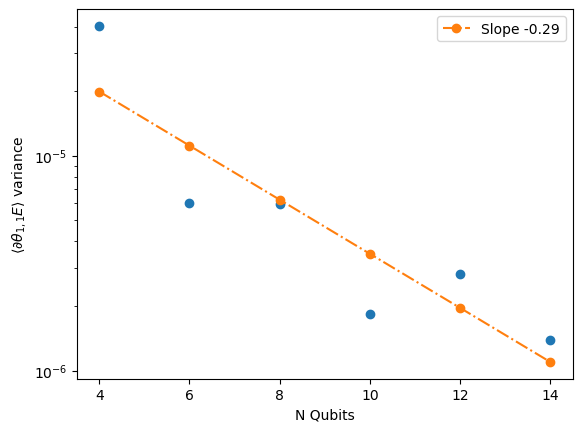

In [12]:
# FIT LINEARE
print(variances)

p = np.polyfit(qubits, np.log(variances), 1)


# PLOT

plt.semilogy(qubits, variances, "o")
plt.semilogy(qubits, np.exp(p[0] * qubits + p[1]), "o-.", label="Slope {:3.2f}".format(p[0]))
plt.xlabel(r"N Qubits")
plt.ylabel(r"$\langle \partial \theta_{1, 1} E\rangle$ variance")
plt.legend()
plt.show()

Il fit lineare non corrisponde esattamente all'andamento dei dati. La varianza però cala, come ci si aspettava, con il numero di qubits, anche se lievemente e in maniera disordinata.

# Circuito espressivo

Si passa ora al circuito più espressivo, in cui ci si aspetta una presenza più rilevante del barren plateau data la complessità del circuito e quindi dell'ottimizzazione.

In [19]:
# PLOT VARIANZA VS NQUBITS SUL CIRCUITO MOLTO ESPRESSIVO 

from catalyst import qjit
import pennylane as qml
from jax import numpy as jnp
import jax.numpy as jnp
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
variances = []


n_qubits      = [4, 6, 8, 10, 12, 14]
steps         = 400
lr_init = 0.1
batch_size=20


for qub in n_qubits: #ciclo esterno per salvare i dati per diversi nqubits
    grad_vals = []
    dev = qml.device("default.qubit", wires=qub)
    
    #AUTOENCODER

    layers = [400, 256, 128, 64, 32, 16, qub]
    model = AE_sinkclass(device=device, hpars={"ae_layers": layers}) 
    model.train_autoencoder(train_loader, valid_loader, epochs=200)
    with torch.no_grad():
        latent_train = model.encoder(torch.tensor(X_tr, dtype=torch.float32)).numpy()
        latent_test  = model.encoder(torch.tensor(X_te, dtype=torch.float32)).numpy()

    # latent shape: (N, 16) — scala in [0, pi] con sigmoid
    X_train = pnp.array(1 / (1 + np.exp(-latent_train)) * np.pi)
    X_test  = pnp.array(1 / (1 + np.exp(-latent_test))  * np.pi)
    Y_train = pnp.array(np.where(Y_tr == 1,  1, -1).astype(np.float64))
    Y_test  = pnp.array(np.where(Y_te == 1,  1, -1).astype(np.float64))
        
    print("X_train shape:", X_train.shape) 
    
    # DEFINIZIONI
    
    def structured_ansatz(weights, wires):
        n = len(wires)
        for i in range(n):
            qml.RY(weights[i, 0], wires=wires[i])
            qml.RZ(weights[i, 1], wires=wires[i])
        for i in range(0, n - 1, 2):
            qml.CNOT(wires=[wires[i], wires[i + 1]])
        for i in range(1, n - 1, 2):
            qml.CNOT(wires=[wires[i], wires[i + 1]])


    def pqc(weights, x_sample):
        x = x_sample.flatten()

        for i in range(qub): #encoding lineare e quadratico
            qml.RY(x[i],      wires=i)
            qml.RZ(x[i] ** 2, wires=i)

        for i in range(qub): #encoding trigonometrico
            qml.RY(pnp.sin(x[i]), wires=i)
            qml.RZ(pnp.tanh(x[i]), wires=i)
        for i in range(qub - 1):
            qml.IsingZZ(x[i] * x[i + 1], wires=[i, i + 1])

        for i in range(qub):
            qml.RY(x[i] * pnp.pi / 2, wires=i)
            qml.RZ(pnp.tanh(x[i]),    wires=i)
        for i in range(qub - 1):
            qml.IsingZZ(x[i] * x[i + 1], wires=[i, i + 1])

        for i in range(3):
            structured_ansatz(weights[i], wires=range(qub))#3 layers


    @qml.qnode(dev, interface="autograd")
    def circuit(weights, x_sample):
        pqc(weights, x_sample)
        return [qml.expval(qml.PauliZ(i)) for i in range(qub)]


    def predict(weights, x_sample):
        return pnp.mean(pnp.array(circuit(weights, x_sample)))


    def cost_function(weights, X, Y, batch_size, eps=1e-7):
        Y_arr   = np.array(Y)
        idx_pos = np.where(Y_arr ==  1)[0]
        idx_neg = np.where(Y_arr == -1)[0]
        half    = batch_size // 2

        chosen_pos = np.random.choice(idx_pos, size=min(half, len(idx_pos)), replace=False)
        chosen_neg = np.random.choice(idx_neg, size=min(half, len(idx_neg)), replace=False)
        idx = np.concatenate([chosen_pos, chosen_neg])
        np.random.shuffle(idx)

        X_batch = pnp.array(X[idx])
        Y_batch = pnp.array((Y_arr[idx] + 1) / 2)

        preds_raw = pnp.array([predict(weights, x) for x in X_batch])

        probs = (preds_raw + 1) / 2            
        probs = pnp.clip(probs, eps, 1 - eps)

        return -pnp.mean(
            Y_batch * pnp.log(probs) + (1 - Y_batch) * pnp.log(1 - probs)
        )


       # CAMPIONAMENTO GRADIENTI a pesi casuali
    grad_fn = qml.grad(cost_function, argnum=0)

    for _ in range(steps):
        weights = pnp.array(
            pnp.random.uniform(-0.05, 0.05, size=(3, qub, 2)), 
            requires_grad=True
        )
        gradient = grad_fn(weights, X_train, Y_train, batch_size)
        grad_vals.append(float(np.mean(np.abs(gradient))))    

    variances.append(np.var(grad_vals))
    print(f"qub={qub}  var={variances[-1]:.2e}")

variances = np.array(variances)
qubits    = np.array(n_qubits)
    


Training AE | latent=4, early_stop=30

X_train shape: (8000, 4)
qub=4  var=4.98e-06

Training AE | latent=6, early_stop=30

X_train shape: (8000, 6)
qub=6  var=5.09e-07

Training AE | latent=8, early_stop=30

X_train shape: (8000, 8)
qub=8  var=2.82e-07

Training AE | latent=10, early_stop=30

X_train shape: (8000, 10)
qub=10  var=1.61e-07

Training AE | latent=12, early_stop=30

X_train shape: (8000, 12)
qub=12  var=1.33e-07

Training AE | latent=14, early_stop=30

X_train shape: (8000, 14)
qub=14  var=5.64e-08


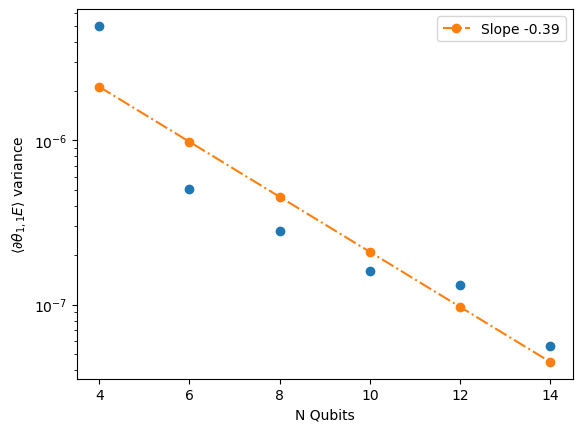

In [21]:
# FIT LINEARE

p = np.polyfit(qubits, np.log(variances), 1)


# PLOT

plt.semilogy(qubits, variances, "o")
plt.semilogy(qubits, np.exp(p[0] * qubits + p[1]), "o-.", label="Slope {:3.2f}".format(p[0]))
plt.xlabel(r"N Qubits")
plt.ylabel(r"$\langle \partial \theta_{1, 1} E\rangle$ variance")
plt.legend()
plt.show()

Il fit lineare si avvicina all'andamento della varianza e si percepisce il calo atteso in funzione del numero di qubits. I valori sono da subito notevolmente più bassi rispetto al caso precedente: questo effetto si attribuisce alla complessità del circuito. Come anticipato, il caso più espressivo è quello in cui il barren plateau influsce di più.

# Circuito con re-uploading

Si ripropone ora la stessa cosa per il terzo circuito del notebook VQAreuploading, composto da due layers. Non era il codice con la migliore accuracy, ma visto che il numero di layers viene moltiplicato per il numero di qubits, il caso a 4 layers avrebbe richiesto molte più features. \
Come prima, inserendo la chiamata all'autoencoder all'interno del loop, si ripete il calcolo della varianza per ogni valore di n_qubits.\
I valori delle fratures che risultano dalla compressione dell'autoencoder corrisponderanno al valore di n_qubits moltiplicato per 2 (due layer di re-upload per ogni qubit):

In [22]:
# PLOT VARIANZA VS NQUBITS SUL CIRCUITO CON RE-UPLOADING

from catalyst import qjit
import pennylane as qml
from jax import numpy as jnp
import jax.numpy as jnp
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve
variances = []


n_qubits      = [2, 4, 6, 8, 10, 12, 14]
n_layers      =  2
steps         = 300
lr_init = 0.1
batch_size=20


for qub in n_qubits: #ciclo esterno per salvare i dati per diversi nqubits
    print(qub*2, "features", qub, "qubits")
    grad_vals = []
    dev = qml.device("default.qubit", wires=qub)
    
    #AUTOENCODER
    
    qub2=qub*2
    layers = [400, 256, 128, 64, 32, qub2]
    model = AE_sinkclass(device=device, hpars={"ae_layers": layers}) 
    model.train_autoencoder(train_loader, valid_loader, epochs=200)
    with torch.no_grad():
        latent_train = model.encoder(torch.tensor(X_tr, dtype=torch.float32)).numpy()
        latent_test  = model.encoder(torch.tensor(X_te, dtype=torch.float32)).numpy()

    # latent shape: (N, 16) — scala in [0, pi] con sigmoid
    X_train = pnp.array(1 / (1 + np.exp(-latent_train)) * np.pi)
    X_test  = pnp.array(1 / (1 + np.exp(-latent_test))  * np.pi)
    Y_train = pnp.array(np.where(Y_tr == 1,  1, -1).astype(np.float64))
    Y_test  = pnp.array(np.where(Y_te == 1,  1, -1).astype(np.float64))
        
        
    # DEFINIZIONI

    def structured_ansatz(weights, wires): #layer
        for i in range(len(wires)):
            qml.RX(weights[i,0], wires=wires[i])
            qml.RY(weights[i,1], wires=wires[i])
            qml.RZ(weights[i,2], wires=wires[i])
        for i in range(len(wires)-1):
            qml.CNOT(wires=[i,i+1])
        qml.CNOT(wires=[len(wires)-1,0])

    def pqc(weights, x_sample): 
        x = x_sample.flatten()
        for layer in range(n_layers):
            for i in range(qub):
                feature_index = layer*qub + i
                qml.RY(x[feature_index], wires=i) #angle encoding
            structured_ansatz(weights[layer], wires=range(qub))

    @qml.qnode(dev, interface="autograd")
    def circuit(weights, x_sample): #circuito completo
        pqc(weights, x_sample) 
        return qml.expval(qml.PauliZ(0)) #misura solo sul primo qubit


    def cost_function(weights, X, Y, batch_size, eps=1e-7):
        Y_arr   = np.array(Y)
        idx_pos = np.where(Y_arr ==  1)[0]
        idx_neg = np.where(Y_arr == -1)[0]
        half    = batch_size // 2

        chosen_pos = np.random.choice(idx_pos, size=min(half, len(idx_pos)), replace=False)
        chosen_neg = np.random.choice(idx_neg, size=min(half, len(idx_neg)), replace=False)
        idx = np.concatenate([chosen_pos, chosen_neg])
        np.random.shuffle(idx)

        X_batch = pnp.array(X[idx])
        Y_batch = pnp.array((Y_arr[idx] + 1) / 2)  

        preds_raw = pnp.array([circuit(weights, x) for x in X_batch])

        probs = (preds_raw + 1) / 2              
        probs = pnp.clip(probs, eps, 1 - eps)

        return -pnp.mean(
            Y_batch * pnp.log(probs) + (1 - Y_batch) * pnp.log(1 - probs)
        )


    # CAMPIONAMENTO GRADIENTI a pesi casuali
    grad_fn = qml.grad(cost_function, argnum=0)

    for _ in range(steps):
        weights = pnp.array(
            pnp.random.uniform(-0.05, 0.05, size=(n_layers, qub, 3)), 
            requires_grad=True
        )
        gradient = grad_fn(weights, X_train, Y_train, batch_size)
        grad_vals.append(float(np.mean(np.abs(gradient))))    

    variances.append(np.var(grad_vals))
    print(f"qub={qub}  var={variances[-1]:.2e}")

variances = np.array(variances)
qubits    = np.array(n_qubits)

4 features 2 qubits

Training AE | latent=4, early_stop=30

qub=2  var=5.69e-02
8 features 4 qubits

Training AE | latent=8, early_stop=30

qub=4  var=3.26e-03
12 features 6 qubits

Training AE | latent=12, early_stop=30

qub=6  var=1.96e-03
16 features 8 qubits

Training AE | latent=16, early_stop=30

qub=8  var=1.05e-03
20 features 10 qubits

Training AE | latent=20, early_stop=30

qub=10  var=2.27e-04
24 features 12 qubits

Training AE | latent=24, early_stop=30

qub=12  var=3.51e-04
28 features 14 qubits

Training AE | latent=28, early_stop=30

qub=14  var=3.13e-04


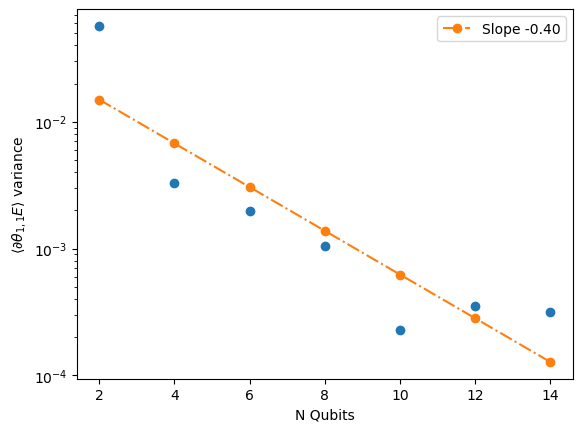

In [23]:
# FIT LINEARE

p = np.polyfit(qubits, np.log(variances), 1)


# PLOT

plt.semilogy(qubits, variances, "o")
plt.semilogy(qubits, np.exp(p[0] * qubits + p[1]), "o-.", label="Slope {:3.2f}".format(p[0]))
plt.xlabel(r"N Qubits")
plt.ylabel(r"$\langle \partial \theta_{1, 1} E\rangle$ variance")
plt.legend()
plt.show()

Di nuovo, il fit non corrisponde esattamente ai dati, ma è comunque evidente il calo della varianza in funzione del numero di qubits, soprattutto nelle prime fasi. 

Sarebbe interessante aumentare ancora il numero di qubits, ma questa operazione richiederebbe tempi di compilazione molto grandi: dovrebbero essere implementate tecniche di velocizzazione avanzate, come Catalyst, lightning devices o JAX.